In [21]:
import numpy as np
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

In [18]:
# training set
X = 2 * np.random.rand(100, 1)
gy = 4 + 3 * X + np.random.randn(100, 1)

# Gradient Descent

In [67]:
learning_rate = 0.1
n_iterations = 10000 # limit the number of iterations
m = len(X)
theta = np.random.randn(2, 1)

Set a very large number of iterations but to interrupt the algorithm when the
gradient vector becomes tiny—that is, when its norm becomes smaller than a tiny
number ϵ (called the tolerance)

In [68]:
tolerance = 0.01
for _ in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    norm = np.linalg.norm(gradients)
    if norm < tolerance:
        break
    theta = theta - learning_rate * gradients
    
theta

array([[4.0742251 ],
       [3.10941182]])

## Scikit-Learn SVD

In [72]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
# lin_reg.intercept_ # b, bias
# lin_reg.coef_ # w, feature weights
lin_reg.intercept_, lin_reg.coef_

(array([4.09933046]), array([[3.08733558]]))

In [73]:
lin_reg.predict(X_new) # 0, 2

array([[ 4.09933046],
       [10.27400162]])

The LinearRegression class is based on the scipy.linalg.lstsq() function
- The SVD approach uses Pseudoinverse
- The complexity is $O(n^2)$

In [74]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.09933046],
       [3.08733558]])

## Stochastic Gradient Descent

In [69]:
n_epochs = 50
t0, t1 = 5, 50

# learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)
# random initialization
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
theta

array([[4.13895058],
       [3.09881189]])

- Scikit-Learn Approach

In [70]:
from sklearn.linear_model import SGDRegressor
# args:
# max_iter: maximum 1,000 epochs
# tol: until the loss drops by less than 0.001 during one epoch
# penalty: None does not use any regularization
# starts with a learning rate of 0.1, using the default learning schedule
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.11053339]), array([3.13964714]))

# Normal Equation

In [19]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best # [[b], [w]]

array([[4.09933046],
       [3.08733558]])

In [28]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.09933046],
       [10.27400162]])

(0.0, 2.0, 0.0, 15.0)

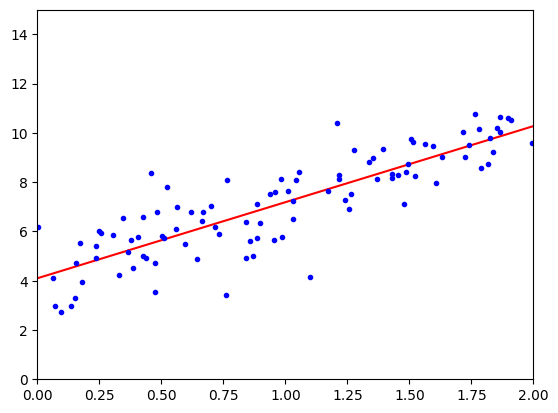

In [29]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])

# Polynomial Regression

In [75]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [76]:
from sklearn.preprocessing import PolynomialFeatures
# degree=2: adding the *square* of each feature in the training set as a new feature
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0], X_poly[0]

(array([1.02841931]), array([1.02841931, 1.05764627]))

In [77]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.28110843]), array([[0.94070122, 0.40179771]]))

(-3.0, 3.0, 0.0, 10.0)

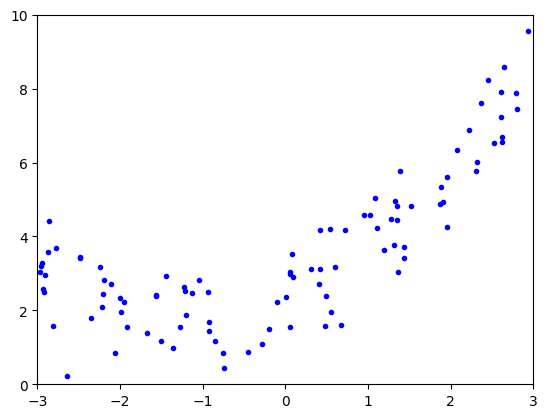

In [82]:
# TODO plot line
plt.plot(X, y, "b.")
plt.axis([-3, 3, 0, 10])